# ReKIS evaluation

In [1]:
import random
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray
import pathlib

import loss
import datasets
import models

First we load data

In [2]:
PATH = '~/ctu/current/rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/'
SCALE_FACTOR = 16

variable = "TM"
Y = xarray.open_mfdataset(PATH + variable + "/*.nc", decode_coords="all")

Y = Y[variable]

data_spatial = Y.rio.set_spatial_dims(x_dim="easting", y_dim="northing")

data = Y.sel(time='2002')
dataset = datasets.ReKIS(Y.sel(time='2002'), SCALE_FACTOR)

Every day in 2002:

In [3]:
dataset.Y.shape

torch.Size([365, 1, 400, 400])

We select randomly 128 from them.

In [4]:
torch.random.manual_seed(42)
k = 128
indices = torch.randperm(dataset.Y.shape[0])[:k]

X, Y = dataset.X.reshape((-1, 1, 400//SCALE_FACTOR, 400//SCALE_FACTOR)), dataset.Y.reshape((-1, 1, 400, 400))
X = torch.index_select(X, 0, indices)
Y = torch.index_select(Y, 0, indices)
X.shape, Y.shape

(torch.Size([128, 1, 25, 25]), torch.Size([128, 1, 400, 400]))

Bicubic interpolation

In [5]:
Y_bicubic = torch.nn.functional.interpolate(
    X,
    scale_factor=SCALE_FACTOR,
    mode="bicubic",
)
print('Bicubic')
print(f'RMSE: \t{torch.sqrt(torch.mean(torch.square(Y - Y_bicubic))):.5f}')
print(f'MAE: \t{torch.mean(torch.abs(Y - Y_bicubic)):.5f}')

Bicubic
RMSE: 	0.26472
MAE: 	0.15578


Load the best model.

In [6]:
CKPT_DIR = '/home/tomas/ctu/current/rci_home/SISR-downscaling/logs/lightning_logs/'

def load_checkpoint(version: int):
    dir = pathlib.Path(CKPT_DIR + f'version_{version}/checkpoints/')
    return [file for file in dir.iterdir() if file.is_file() and file.suffix == '.ckpt'][0]

torch.set_float32_matmul_precision("high")
model = models.ConstrainedModel(model=models.EDSR(channels=1, scale_factor=SCALE_FACTOR, features=128, residual_blocks=64, loss=loss.LossCombination([1], [
    loss.L1Loss()])), constraint=models.AddConstraintLayer(SCALE_FACTOR))
# model = models.EDSR(channels=1, scale_factor=SCALE_FACTOR, features=128, residual_blocks=64, loss=loss.LossCombination([1], [loss.L1Loss()]))
ckpt = load_checkpoint(629)
checkpoint = torch.load(ckpt, map_location='cuda')
model.load_state_dict(checkpoint['state_dict'], strict=False)
model.eval()

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'constraint' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['constraint'])`.


ConstrainedModel(
  (train_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=train/
  )
  (val_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=val/
  )
  (test_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=test/
  )
  (model): EDSR(
    (train_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=train/
    )
    (val_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=val/
    )
    (test_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=test/
    )
    (loss): LossCombination(


Do the downscaling.

In [7]:
with torch.no_grad():
    Y_edsr = model(X).detach()

print('EDSR')
print(f'RMSE: \t{torch.sqrt(torch.mean(torch.square(Y_edsr - Y))):.5f}')
print(f'MAE: \t{torch.mean(torch.abs(Y_edsr - Y)):.5f}')

EDSR
RMSE: 	0.03080
MAE: 	0.02587


We will focus on the WORST prediction from these 128.

In [8]:
rmses = np.array([torch.sqrt(torch.mean(torch.square(Y_edsr[i] - Y[i]))) for i in range(len(Y))])
i = np.argmax(rmses)
print(f'i={i}, RMSE={rmses[i]:.5f}')

i=100, RMSE=0.06387


EDSR for i=100
RMSE: 	0.06387
MAE: 	0.04760
Bicubic for i=100
RMSE: 	0.14165
MAE: 	0.08958


[]

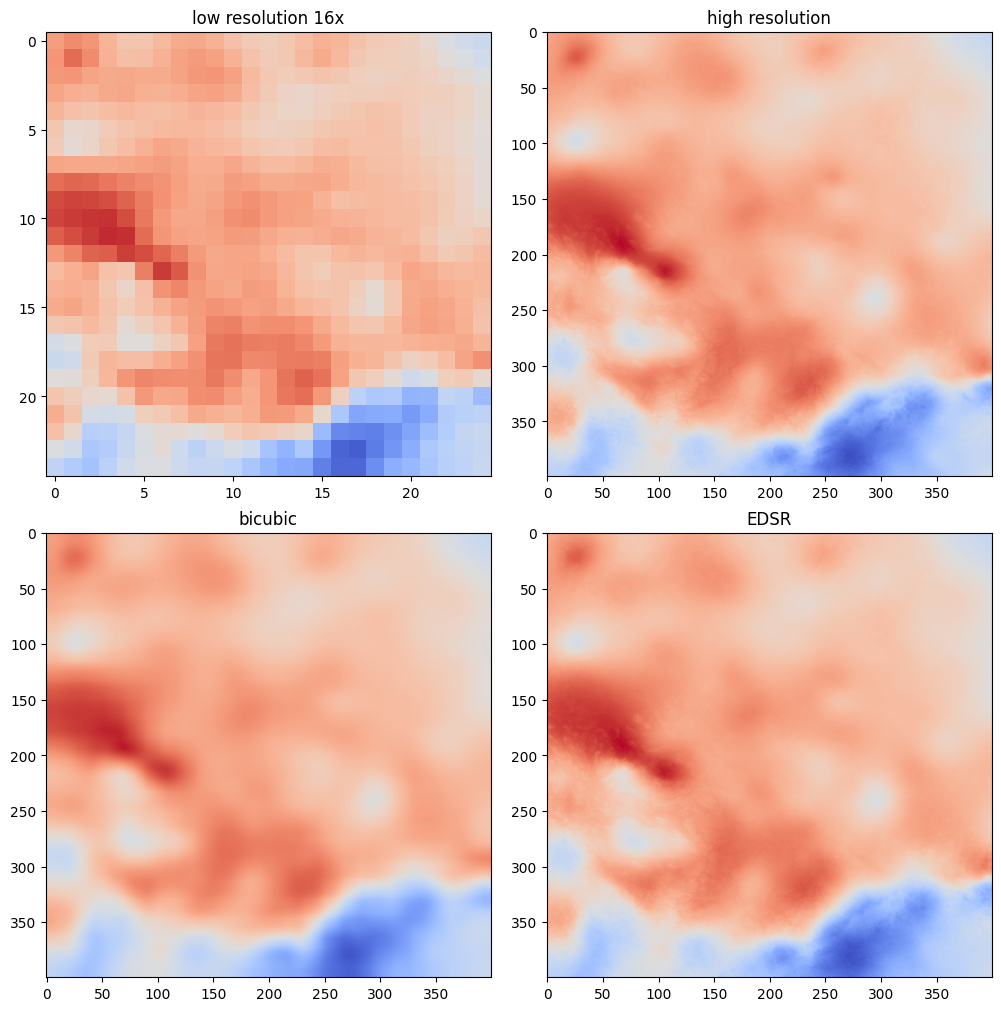

In [9]:
# i = random.randint(0, len(Y))
print(f'EDSR for i={i}')
print(f'RMSE: \t{torch.sqrt(torch.mean(torch.square(Y_edsr[i] - Y[i]))):.5f}')
print(f'MAE: \t{torch.mean(torch.abs(Y_edsr[i] - Y[i])):.5f}')

print(f'Bicubic for i={i}')
print(f'RMSE: \t{torch.sqrt(torch.mean(torch.square(Y_bicubic[i] - Y[i]))):.5f}')
print(f'MAE: \t{torch.mean(torch.abs(Y_bicubic[i] - Y[i])):.5f}')

fig, axes = plt.subplots(ncols=2, nrows=2, constrained_layout=True, figsize=(10, 10))

vmin = min(X[i].min(), Y[i].min(), Y_edsr[i].min(), Y_bicubic[i].min())
vmax = max(X[i].max(), Y[i].max(), Y_edsr[i].max(), Y_bicubic[i].max())

axes[0, 0].imshow(X[i].squeeze(), cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[0, 0].set_title(f"low resolution {SCALE_FACTOR}x")

axes[0, 1].imshow(Y[i].squeeze(), cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[0, 1].set_title("high resolution")

axes[1, 0].imshow(Y_bicubic[i].squeeze(), cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[1, 0].set_title("bicubic")

axes[1, 1].imshow(Y_edsr[i].squeeze(), cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[1, 1].set_title("EDSR")

plt.plot()

It is evident that even for the worst EDSR prediction it has much more high-resolution artifacts than the bicubic interpolation.


Now we will show a randomly selected prediction, to show that the worst one is really the worst and the output is usually nicer.

EDSR for i=44
RMSE: 	0.02985
MAE: 	0.02551
Bicubic for i=44
RMSE: 	0.30613
MAE: 	0.18484


[]

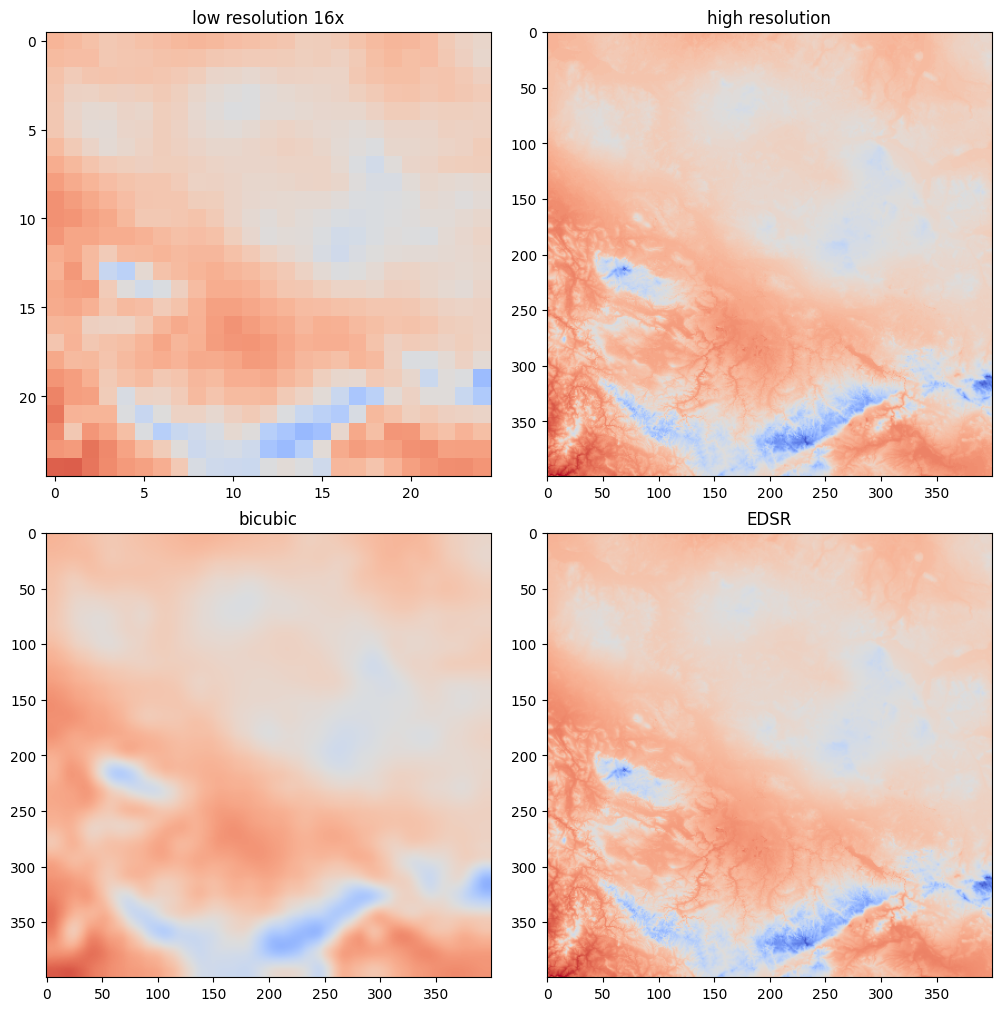

In [10]:
i = random.randint(0, len(Y))

print(f'EDSR for i={i}')
print(f'RMSE: \t{torch.sqrt(torch.mean(torch.square(Y_edsr[i] - Y[i]))):.5f}')
print(f'MAE: \t{torch.mean(torch.abs(Y_edsr[i] - Y[i])):.5f}')

print(f'Bicubic for i={i}')
print(f'RMSE: \t{torch.sqrt(torch.mean(torch.square(Y_bicubic[i] - Y[i]))):.5f}')
print(f'MAE: \t{torch.mean(torch.abs(Y_bicubic[i] - Y[i])):.5f}')

fig, axes = plt.subplots(ncols=2, nrows=2, constrained_layout=True, figsize=(10, 10))

vmin = min(X[i].min(), Y[i].min(), Y_edsr[i].min(), Y_bicubic[i].min())
vmax = max(X[i].max(), Y[i].max(), Y_edsr[i].max(), Y_bicubic[i].max())

axes[0, 0].imshow(X[i].squeeze(), cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[0, 0].set_title(f"low resolution {SCALE_FACTOR}x")

axes[0, 1].imshow(Y[i].squeeze(), cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[0, 1].set_title("high resolution")

axes[1, 0].imshow(Y_bicubic[i].squeeze(), cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[1, 0].set_title("bicubic")

axes[1, 1].imshow(Y_edsr[i].squeeze(), cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[1, 1].set_title("EDSR")

plt.plot()

For a random prediction it is very difficult to find differences between HR and downscaled images.
Bicubic is significantly blurred.

We will now show the differences.

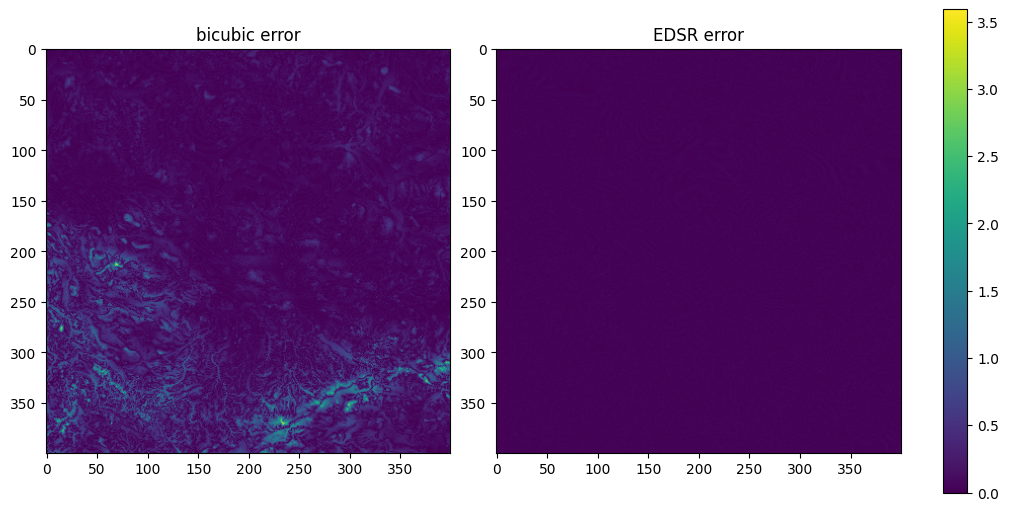

In [11]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 5), constrained_layout=True)

error_bicubic = abs(Y[i] - Y_bicubic[i])
error_edsr = abs(Y[i] - Y_edsr[i])

maximum = max(torch.max(error_bicubic), torch.max(error_edsr))
norm = matplotlib.colors.Normalize(vmin=0, vmax=maximum)


axes[0].imshow(error_bicubic.squeeze(), norm=norm)
axes[0].set_title("bicubic error")


im = axes[1].imshow(error_edsr.squeeze(), norm=norm)
axes[1].set_title("EDSR error")

fig.colorbar(im, ax=axes)

plt.show()

The bicubic model has large errors in mountainous areas, whereas the EDSR model's error is not observable at this range.

We will modify this range.

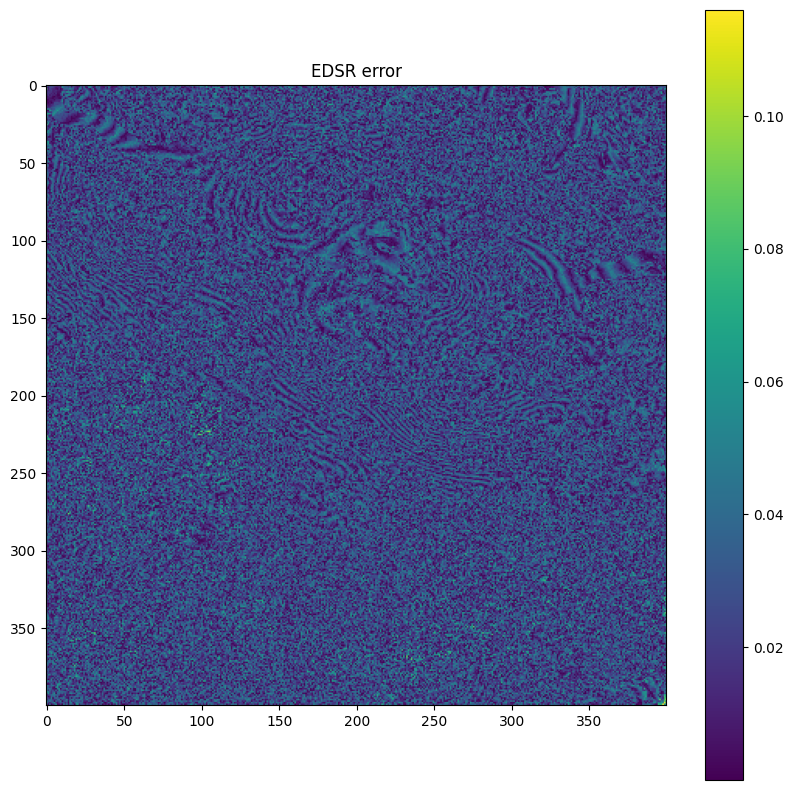

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(error_edsr.squeeze())
ax.set_title("EDSR error")
fig.colorbar(im)
plt.show()

The errors appear to be random noise.

We now compute the mean of this errors.

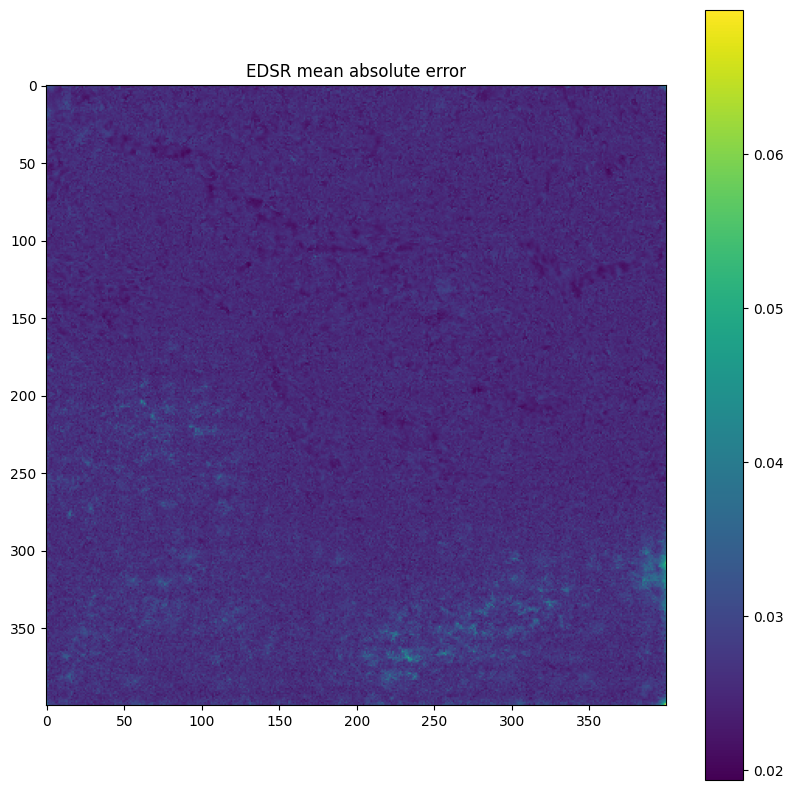

In [13]:
error_edsr = (Y_edsr - Y).abs().mean(dim=0)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(error_edsr.squeeze())
fig.colorbar(im)
ax.set_title("EDSR mean absolute error")
plt.show()

We can see that the EDSR model also makes more mistakes in the mountainous region.

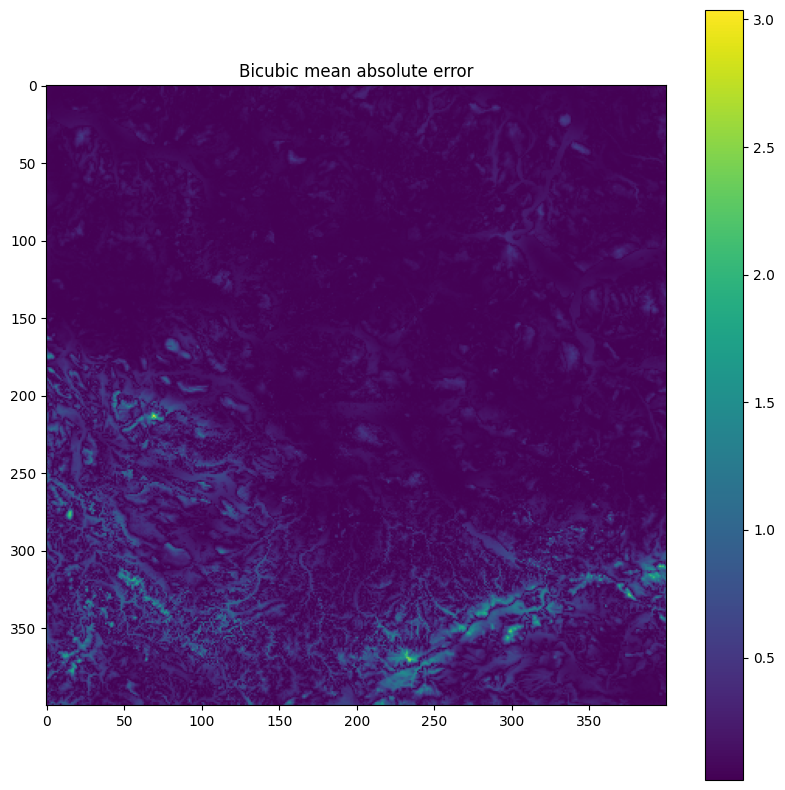

In [14]:
error_bicubic = (Y_bicubic - Y).abs().mean(dim=0)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(error_bicubic.squeeze())
fig.colorbar(im)
ax.set_title("Bicubic mean absolute error")
plt.show()

However the bicubic model mean error is worse and we can almost a HR map of the mountains.